# Project plasma-cell programs by non-negative least squares

**Biology rationale.** Program projection extends cNMF-defined states to plasma cells without directly assigned clonotypes, including residual disease cells.

**Aim.** Estimate reference program activities in all plasma cells and compare projected states across clinical groups.

**Data input.** `./250817-AL-all78umap-singletonly-umap.rds`, `sce1_ALl19clustermeta.data.csv`, `GEP_PostMinusPre_stats_by_response_t1114.csv`, `GEP_PostMinusPre_GoodPoor_All_t1114_non_t1114.pdf`, `Pretreatment_GEP_Poor_vs_Good_stats_by_t1114.csv`



**Data outputs.** `plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
set.seed(123)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
# Set these *before* library(reticulate) or library(sceasy)
Sys.setenv(RETICULATE_PYTHON = "/home/miniconda3/envs/carlin/bin/python")
options(reticulate.conda_binary = "/home/miniconda3/bin/conda")

library(reticulate)
py_config()  # should now show your conda 'jupyter' Python


python:         /home/miniconda3/envs/carlin/bin/python
libpython:      /home/miniconda3/envs/carlin/lib/libpython3.8.so
pythonhome:     /home/miniconda3/envs/carlin:/home/miniconda3/envs/carlin
version:        3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35)  [GCC 12.3.0]
numpy:          /home/miniconda3/envs/carlin/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by RETICULATE_PYTHON

In [3]:
sce1<-readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

In [4]:
clusters_to_keep <- setdiff(0:86, c(60,48,61,50,38,36,37,9,14,26,56,5,65,12,83,55,32,31,42,80,46,57,16,11,4,6,34,64,52,68,64,0,8,41,2,63,53,2,1,3,66,67) )  # Replace with the cluster IDs you want to keep
# Define the barcodes to keep
ALl19cluster<-read.csv(file='sce1_ALl19clustermeta.data.csv')
barcodes_to_keep <- ALl19cluster$X
# <-- replace with your real barcodes

# Subset Seurat object: keep cells in chosen clusters OR in the barcode list
sce1_plasma <- subset(
  sce1,
  subset = (seurat_clusters %in% clusters_to_keep) | (Cells(sce1) %in% barcodes_to_keep)
)

scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


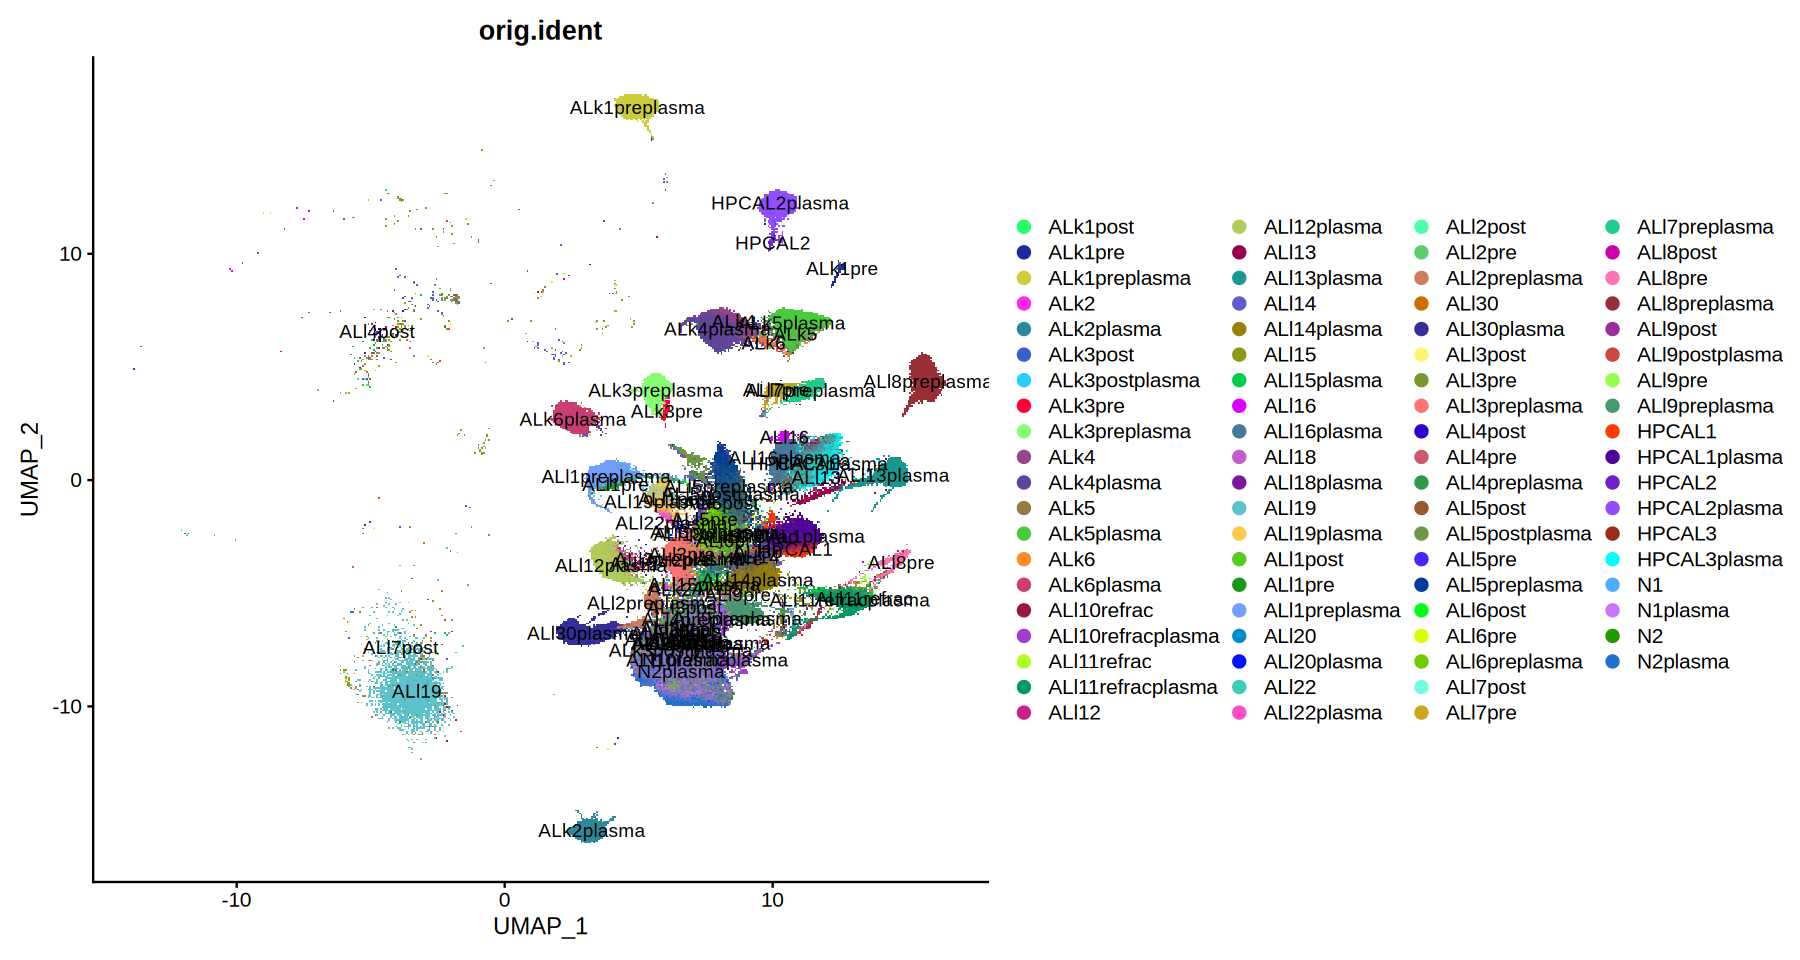

In [5]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 

## 2. Normalization, integration, and dimensional reduction


In [6]:
# run standard anlaysis workflow
sce1_plasma <- NormalizeData(sce1_plasma)
sce1_plasma <- FindVariableFeatures(sce1_plasma)

Normalizing layer: counts

Finding variable features for layer counts



In [7]:
# Step 1: Identify genes starting with "IG"
ig_genes <- grep("^IGK|^IGH|^IGL", rownames(sce1_plasma), value = TRUE)

# Step 2: Exclude these genes from variable features
current_variable_features <- VariableFeatures(sce1_plasma)
filtered_variable_features <- setdiff(current_variable_features, ig_genes)
VariableFeatures(sce1_plasma) <- filtered_variable_features

# Step 3: Proceed with PCA and UMAP
sce1_plasma <- ScaleData(sce1_plasma, features = VariableFeatures(sce1_plasma))
sce1_plasma <- RunPCA(sce1_plasma, features = VariableFeatures(sce1_plasma))

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  RHOB, CITED2, DUSP5, CD79A, QPCT, JSRP1, FCRLA, PELI1, CD9, NFKBIA 
	   CDKN1A, ATF5, FBP1, CAV1, SLC22A17, LMNA, P2RX1, HSPB1, DPEP1, NR4A1 
	   FAM92B, IRF4, BMP6, PHGDH, ABCB9, OTUD1, PTP4A3, CTHRC1, AMPD1, FAM30A 
Negative:  NKG7, GNLY, IL32, FGFBP2, CCL5, PTPRC, GZMA, GZMH, GZMB, CD3D 
	   KLRD1, CST7, HCST, CD2, CD8B, CD3G, FCGR3A, CD52, TRBC2, GIMAP7 
	   CD3E, PRF1, KLRG1, GZMM, PTGDS, CD8A, GIMAP4, LCP1, HLA-DPB1, MYOM2 
PC_ 2 
Positive:  CD99, TMSB4X, SLC22A17, CTSW, CD79A, P2RX1, WFDC2, TMC6, RBP1, CD81 
	   MYADM, SLC22A31, WARS, TNFRSF18, LINC01781, PCSK1N, CD44, TGFBR3L, TCN2, PGLYRP2 
	   ERN1, TIMP1, FAM30A, HLA-DMA, CTHRC1, FCER2, MT1F, TMEM176B, ATF5, ALOX5AP 
Negative:  MT-ND5, PTP4A3, RPS17, NEB, MT-ND2, MT-ND4, NEAT1, MT-CO3, RPL23, HIST1H1C 
	   GAS5, MT-ATP6, CST6, AL353753.1, DHRS9, LINC01088, NUDT12, MT-ND3, TXNIP, HIST

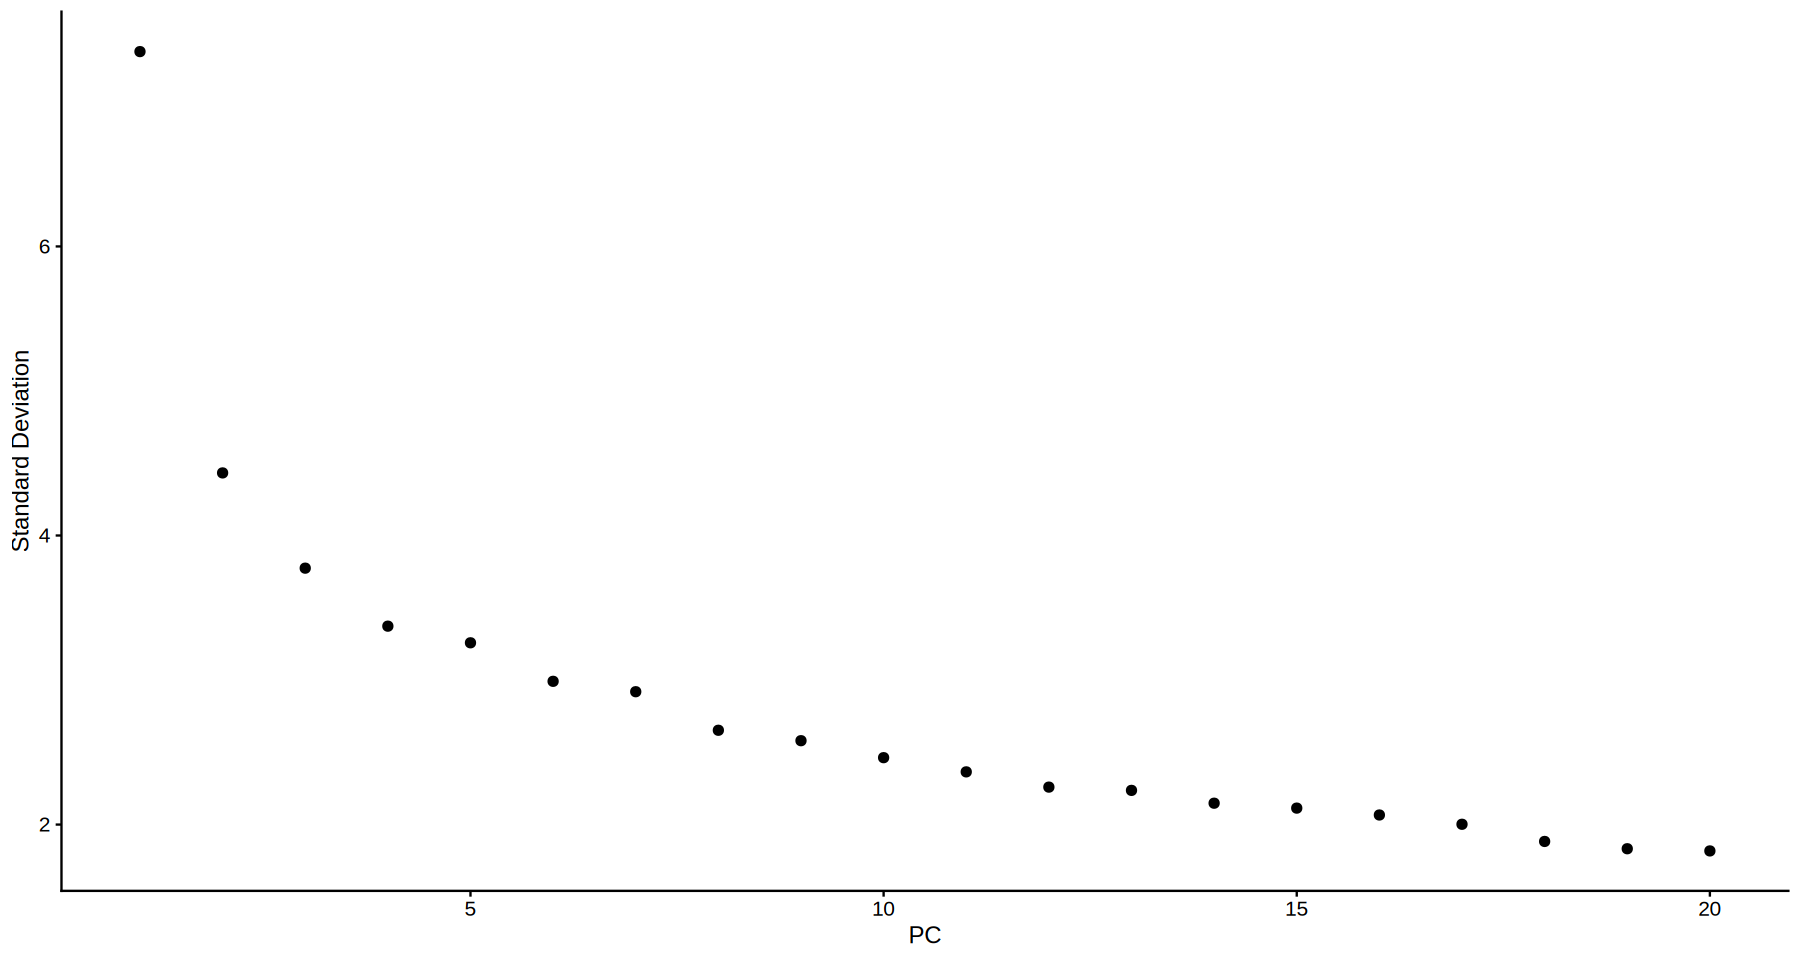

In [8]:
ElbowPlot(sce1_plasma)

## 3. Sample metadata and clinical groups


In [9]:
sce1_plasma <- FindNeighbors(sce1_plasma, dims = 1:15, reduction = "pca")
sce1_plasma <- FindClusters(sce1_plasma, resolution = 1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 232300
Number of edges: 6542590

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9443
Number of communities: 52
Elapsed time: 79 seconds


In [10]:
sce1_plasma <- RunUMAP(sce1_plasma, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
11:33:12 UMAP embedding parameters a = 0.9922 b = 1.112

11:33:12 Read 232300 rows and found 15 numeric columns

11:33:12 Using Annoy for neighbor search, n_neighbors = 30

11:33:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:33:31 Writing NN index file to temp file /tmp/RtmpDn1ESH/file2e875b23af2b9

11:33:31 Searching Annoy index using 1 thread, search_k = 3000

11:34:57 Annoy recall = 100%

11:34:58 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

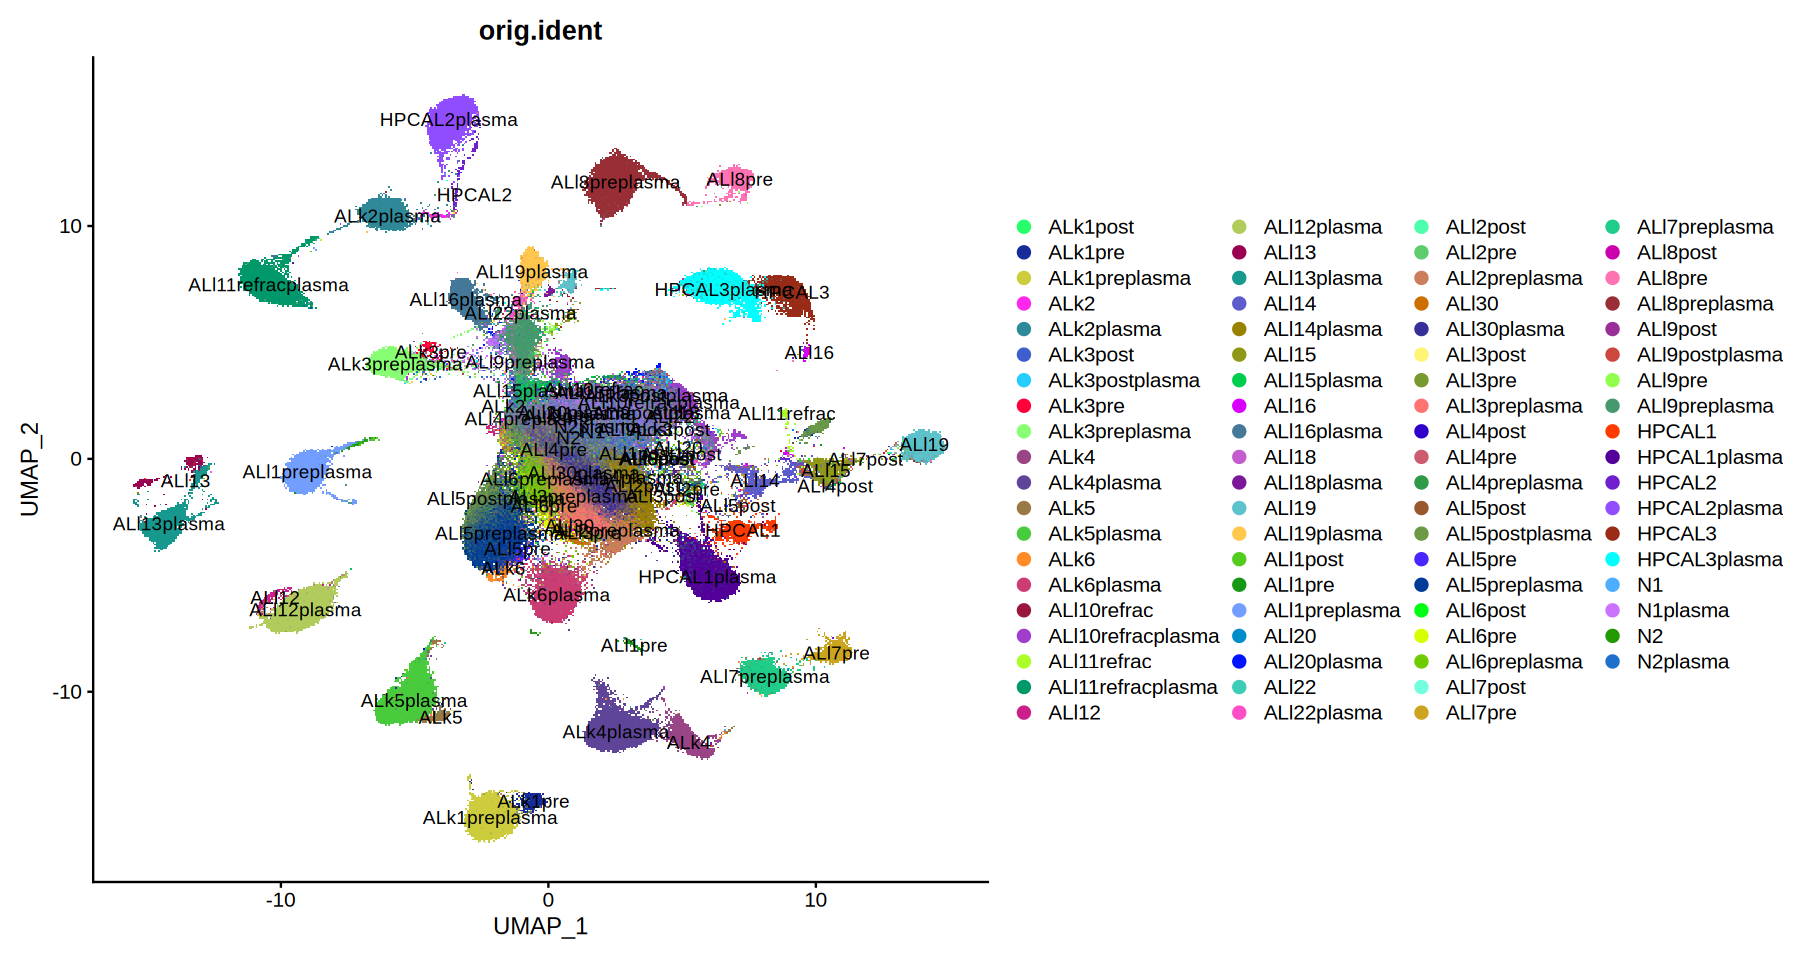

In [11]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 

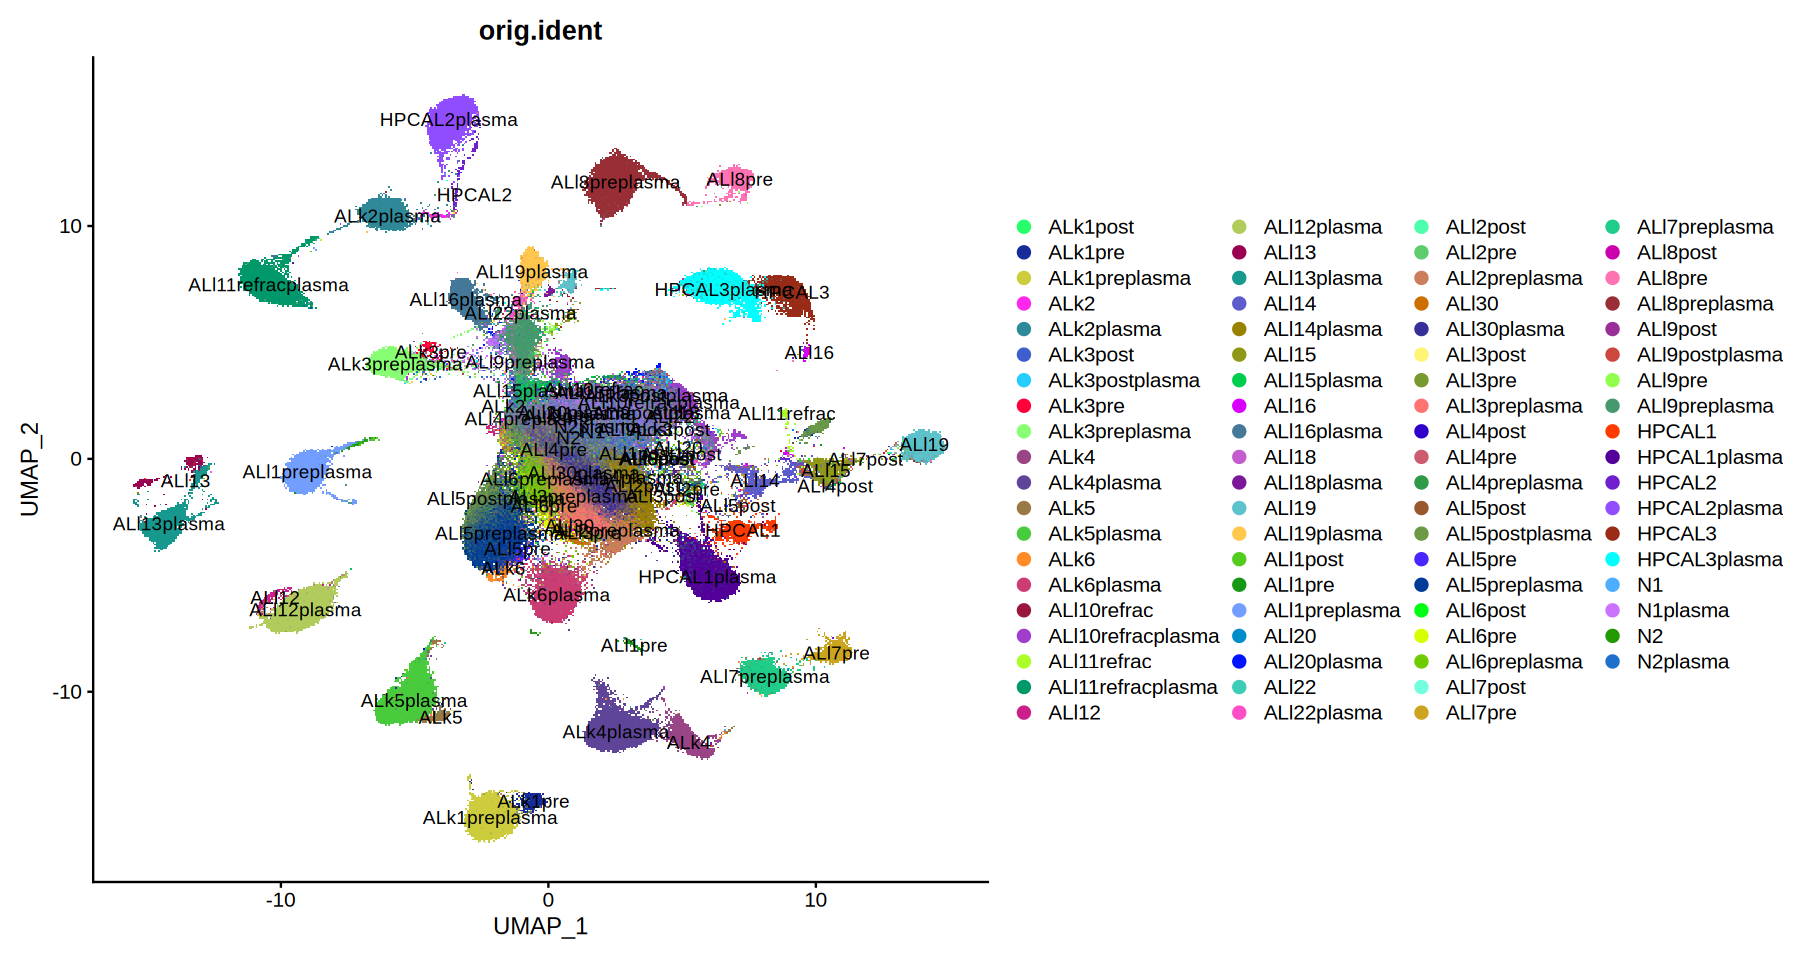

In [12]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 


NOTE: DimPlot_scCustom returns split plots as layout of all plots each
with their own axes as opposed to Seurat which returns with shared x or y axis.
To return to Seurat behvaior set `split_seurat = TRUE`.

-----This message will be shown once per session.-----


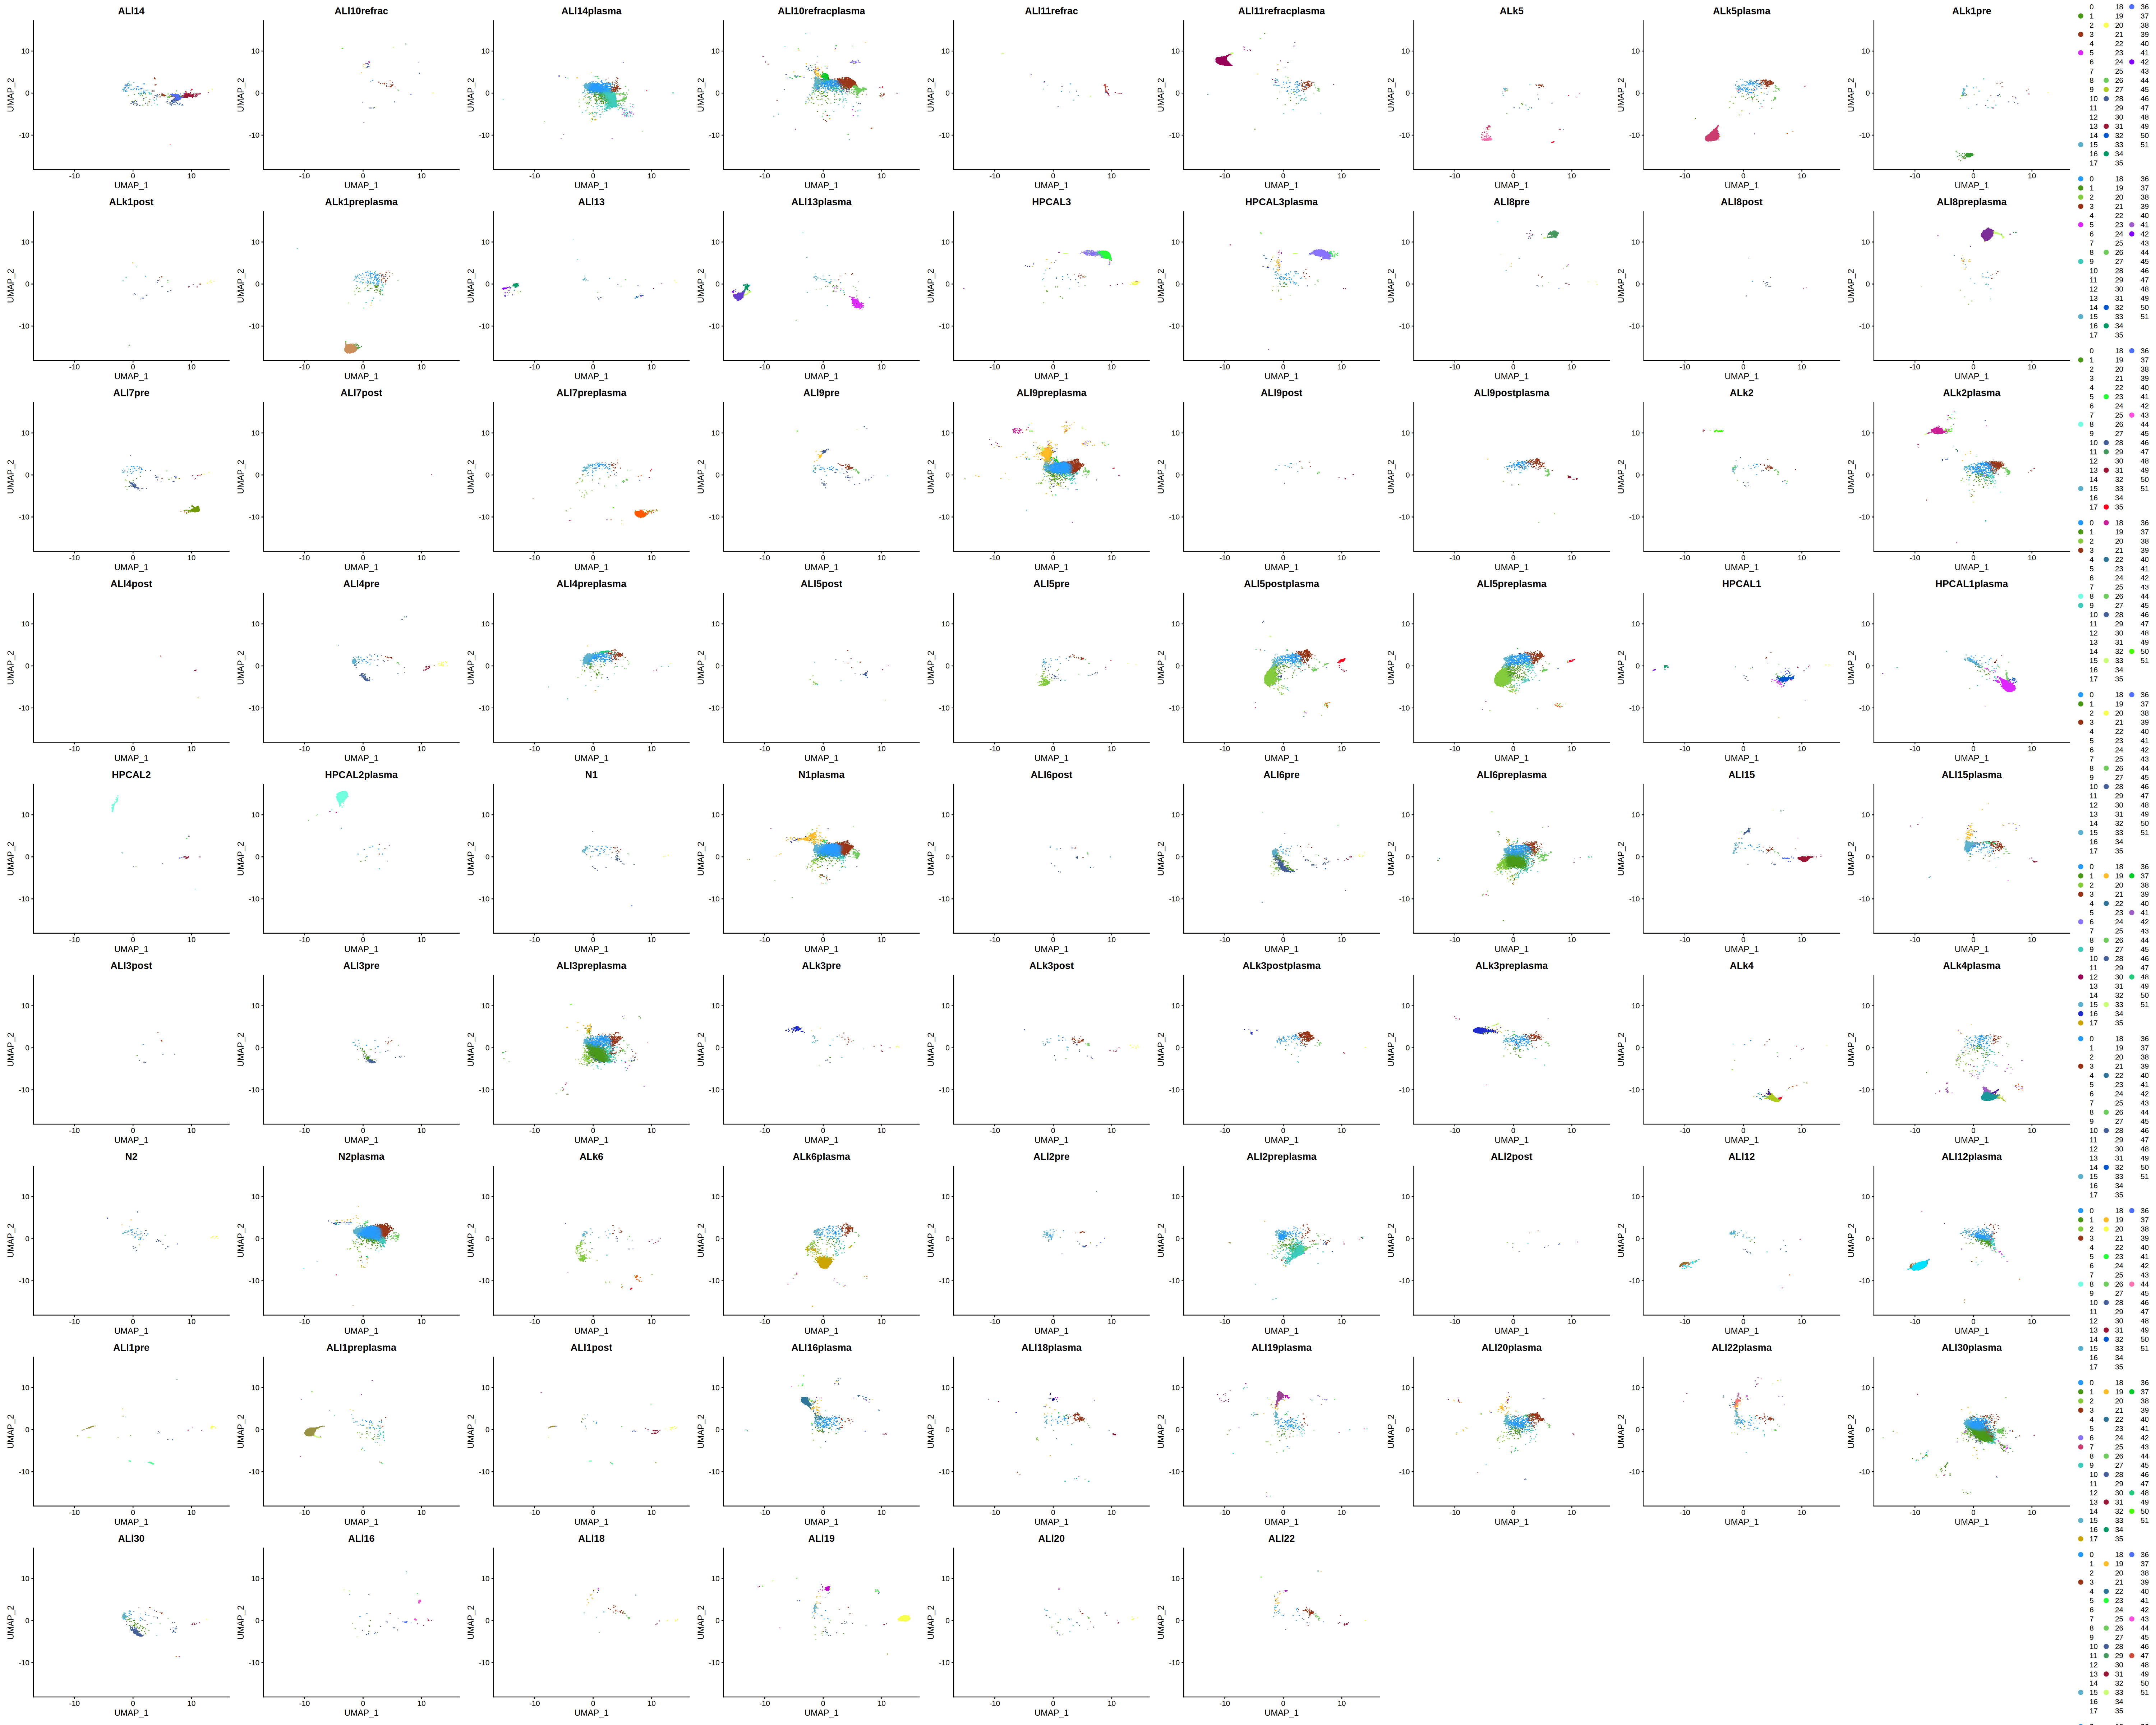

In [13]:
library(scCustomize)
options(repr.plot.height=40,repr.plot.width=50)
DimPlot_scCustom(sce1_plasma, pt.size=2,reduction = "UMAP", split.by = c("orig.ident"),label=F) 

## 4. Sample metadata and clinical groups


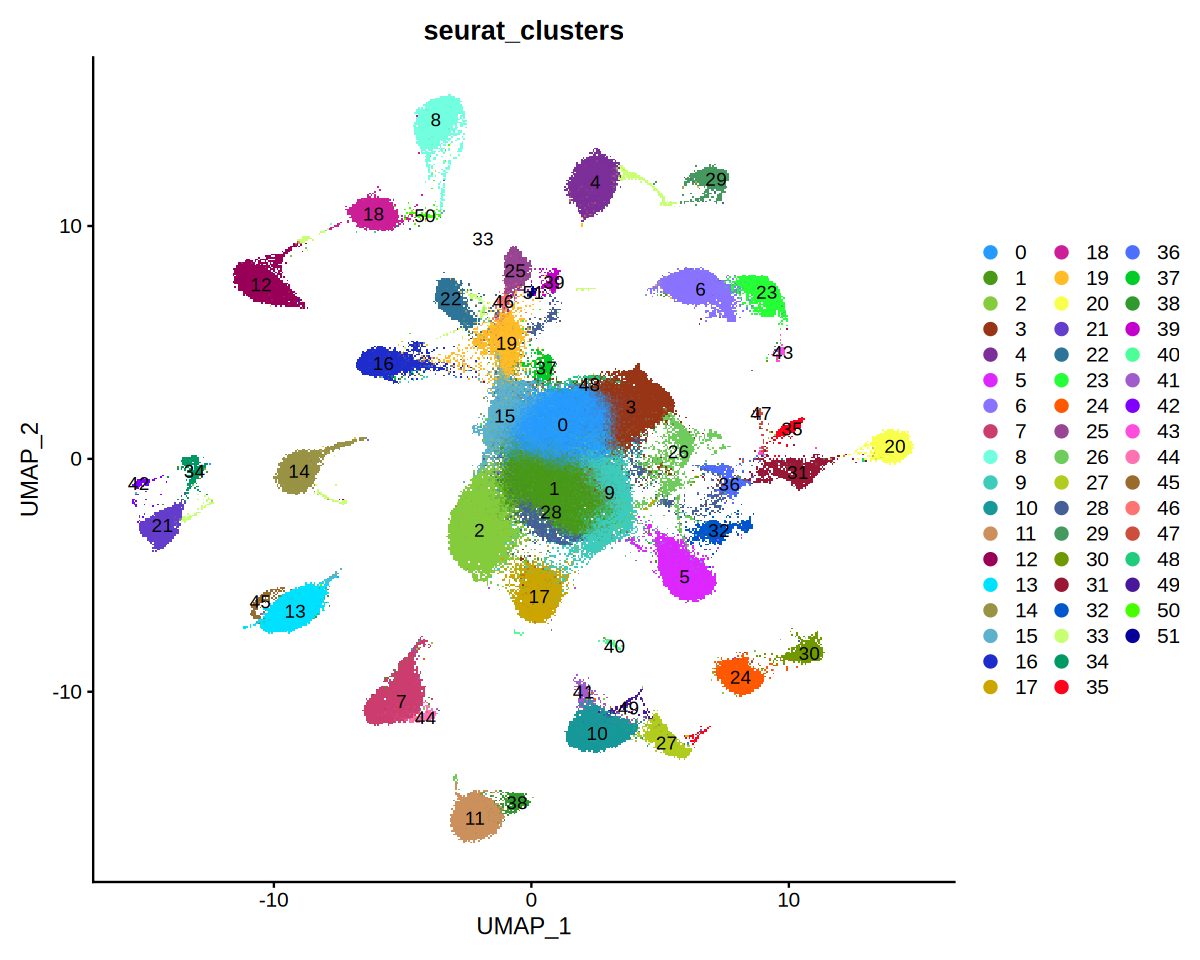

In [14]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("seurat_clusters"),label=T) 

In [15]:
sce1_plasma

An object of class Seurat 
36601 features across 232300 samples within 1 assay 
Active assay: RNA (36601 features, 1755 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [16]:
sce1_plasma@meta.data$subtype<-sce1_plasma@meta.data$orig.ident

## 5. Visualization and figure generation


In [17]:
sce1_plasma@meta.data$subtype<-gsub('HPCAL1','HPCAL',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('HPCAL2','HPCAL',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('HPCAL3','HPCAL',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('HPCALplasma','HPCAL',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('N1','N',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('N2','N',sce1_plasma@meta.data$subtype)
sce1_plasma@meta.data$subtype<-gsub('Nplasma','N',sce1_plasma@meta.data$subtype)

In [18]:
sce1_plasma@meta.data$subtype <- substr(sce1_plasma@meta.data$subtype, 1, 3)

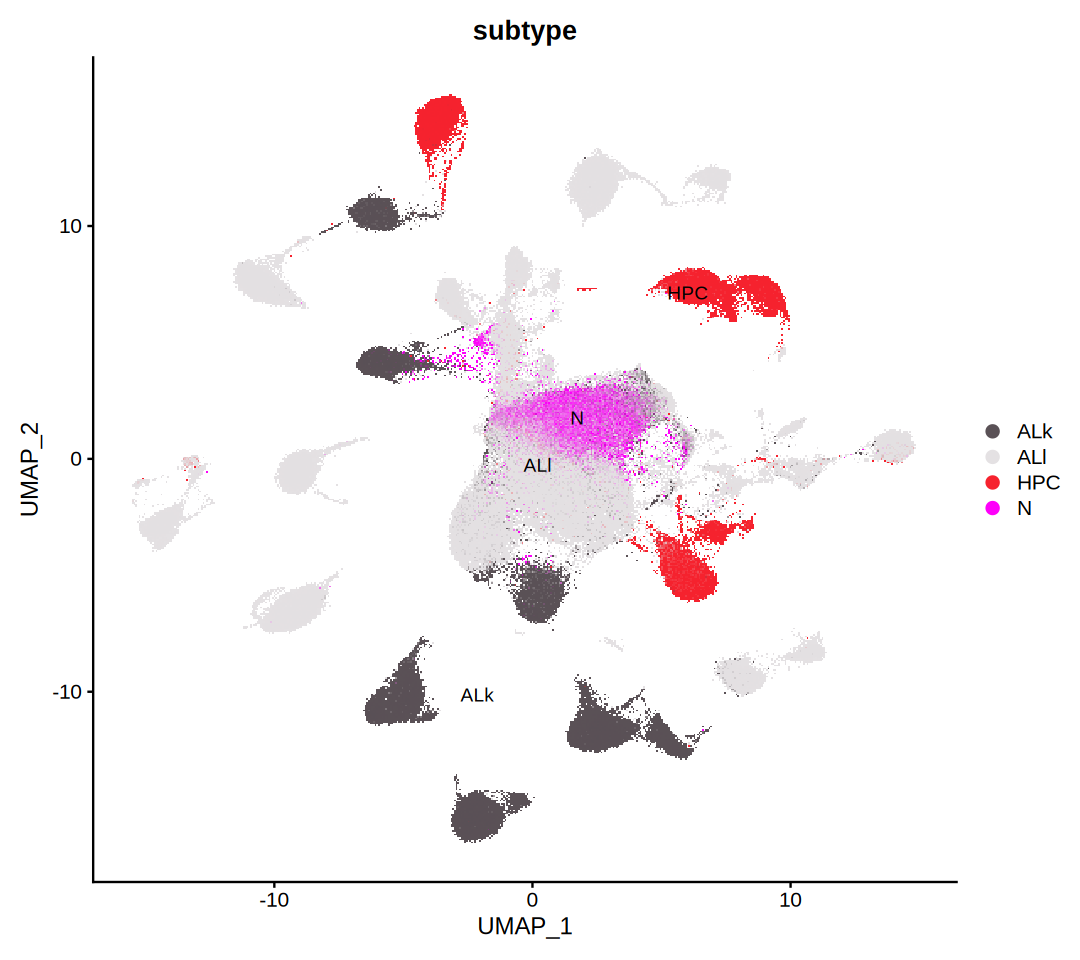

In [19]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=9)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("subtype"),label=T,order=T) 

In [20]:
#assgin baseline translocation to the treated sample
sce1_plasma@meta.data$mutation<-sce1_plasma@meta.data$orig.ident
sce1_plasma@meta.data$mutation<-gsub('ALl10refracplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl10refrac','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl11refracplasma','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl11refrac','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk4plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk4','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk5plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk5','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk2plasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk2','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk6plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk6','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk1preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk1pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk1postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk1post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk3preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk3pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk3postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALk3post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl1preplasma','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl1pre','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl1postplasma','1q21(gain)_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl1post','1q21(gain)_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl2preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl2pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl2postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl2post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl3preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl3pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl3postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl3post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl5preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl5pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl5postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl5post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl7preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl7pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl7postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl7post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl8preplasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl8pre','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl8postplasma','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl8post','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl9preplasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl9pre','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl9postplasma','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl9post','None_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl4preplasma','NA',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl4pre','NA',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl4postplasma','NA',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl4post','NA',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl6preplasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl6pre','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl6postplasma','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl6post','IgH/CCND1(t(11;14))_Post',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl12plasma','IgH/FGFR3(t(4;14))/1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl12','IgH/FGFR3(t(4;14))/1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl13plasma','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl13','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl14plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl14','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl15plasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl15','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl16plasma','17p13.1(del)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl16','17p13.1(del)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl18plasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl18','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl19plasma','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl19','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl20plasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl20','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl22plasma','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl22','None_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL1plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL1','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl30plasma','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('ALl30','IgH/CCND1(t(11;14))_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL2plasma','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL2','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL3plasma','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('HPCAL3','1q21(gain)_Pre',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('N1plasma','Normal',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('N1','Normal',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('N2plasma','Normal',sce1_plasma@meta.data$mutation)
sce1_plasma@meta.data$mutation<-gsub('N2','Normal',sce1_plasma@meta.data$mutation)

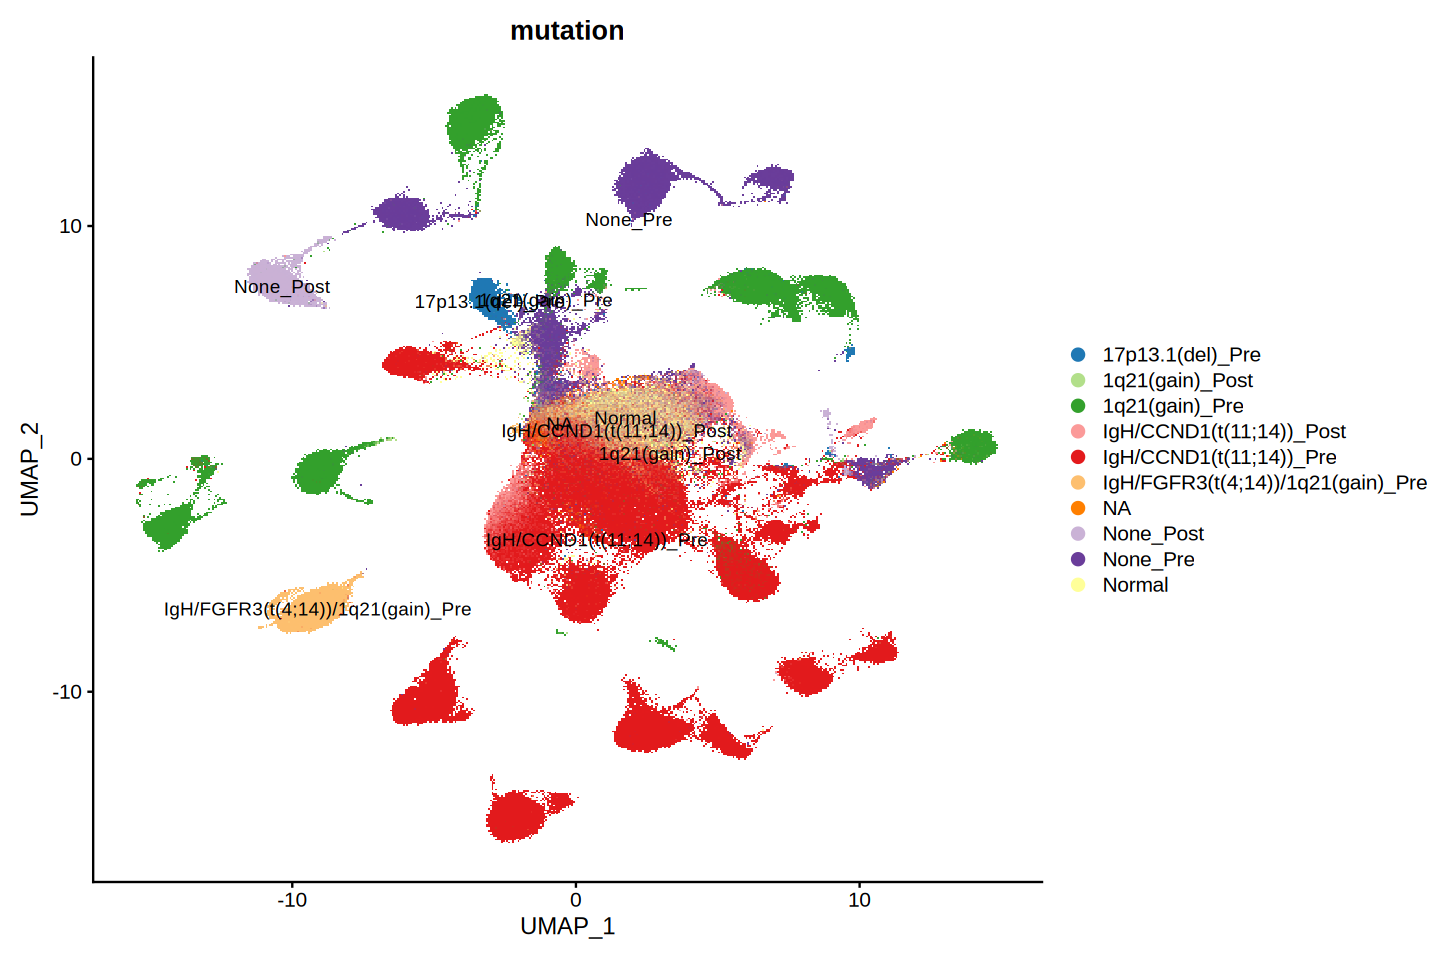

In [21]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=12)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("mutation"),label=T,order=T, colors_use = RColorBrewer::brewer.pal(n = 11, name = "Paired")[2:11])

## 6. Sample metadata and clinical groups


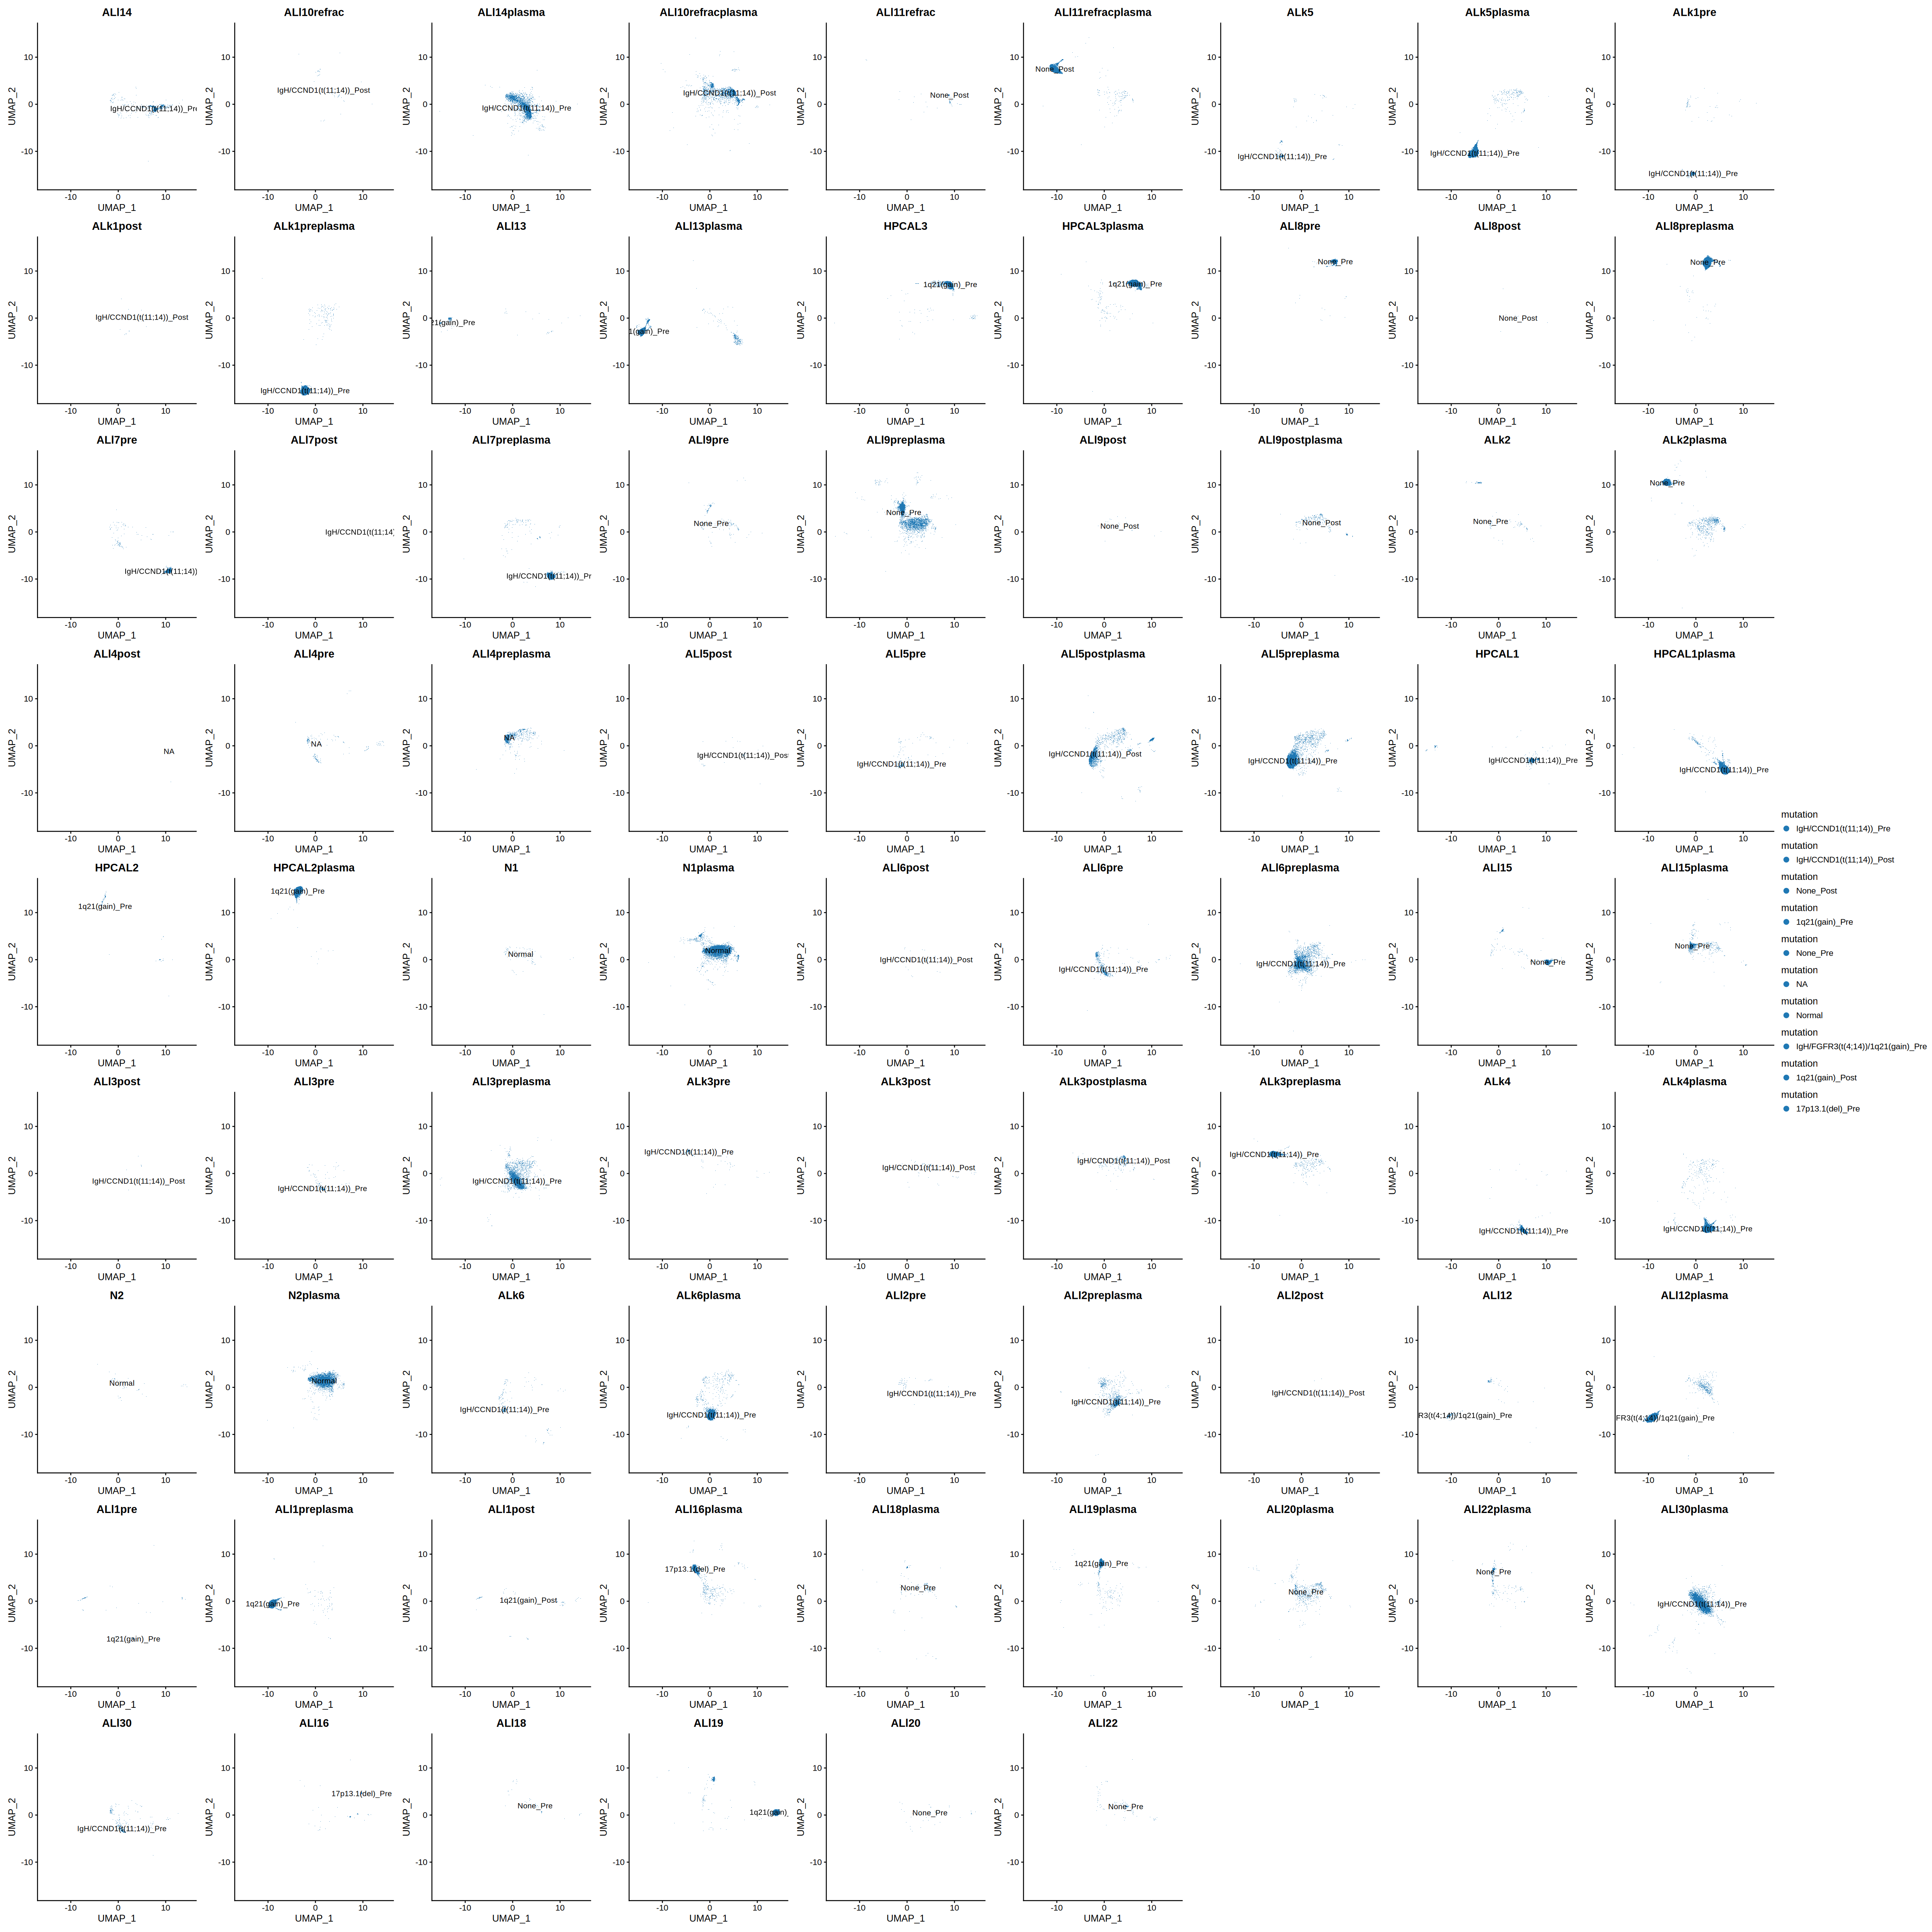

In [22]:
library(scCustomize)
options(repr.plot.height=40,repr.plot.width=40)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("mutation"),split.by='orig.ident',label=T,order=T, colors_use = RColorBrewer::brewer.pal(n = 11, name = "Paired")[2:11])

In [23]:
length(ig_genes)

[1] 411

In [24]:
sce1_plasma@meta.data$"seurat_clusters"<-paste('cluster',sce1_plasma@meta.data$"seurat_clusters",sep='')

## 7. Gene-expression program analysis


In [25]:
sce1_plasma@meta.data$"sample_id"<-sce1_plasma@meta.data$"orig.ident"

In [26]:
sce1_plasma

An object of class Seurat 
36601 features across 232300 samples within 1 assay 
Active assay: RNA (36601 features, 1755 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [27]:
GEP<-read.csv('plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv')

In [28]:
rownames(GEP)<-GEP$X
GEP$X<-NULL

In [29]:
sce1_plasma@meta.data<-cbind(sce1_plasma@meta.data,GEP[rownames(sce1_plasma@meta.data),])

## 8. Gene-expression program analysis


In [30]:
sce1_plasma@meta.data$barcode<-NULL
sce1_plasma@meta.data$orig.ident<-NULL


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(all_of(features), mean, na.rm = TRUE)`.
ℹ In group 1: `sample_id = "ALk

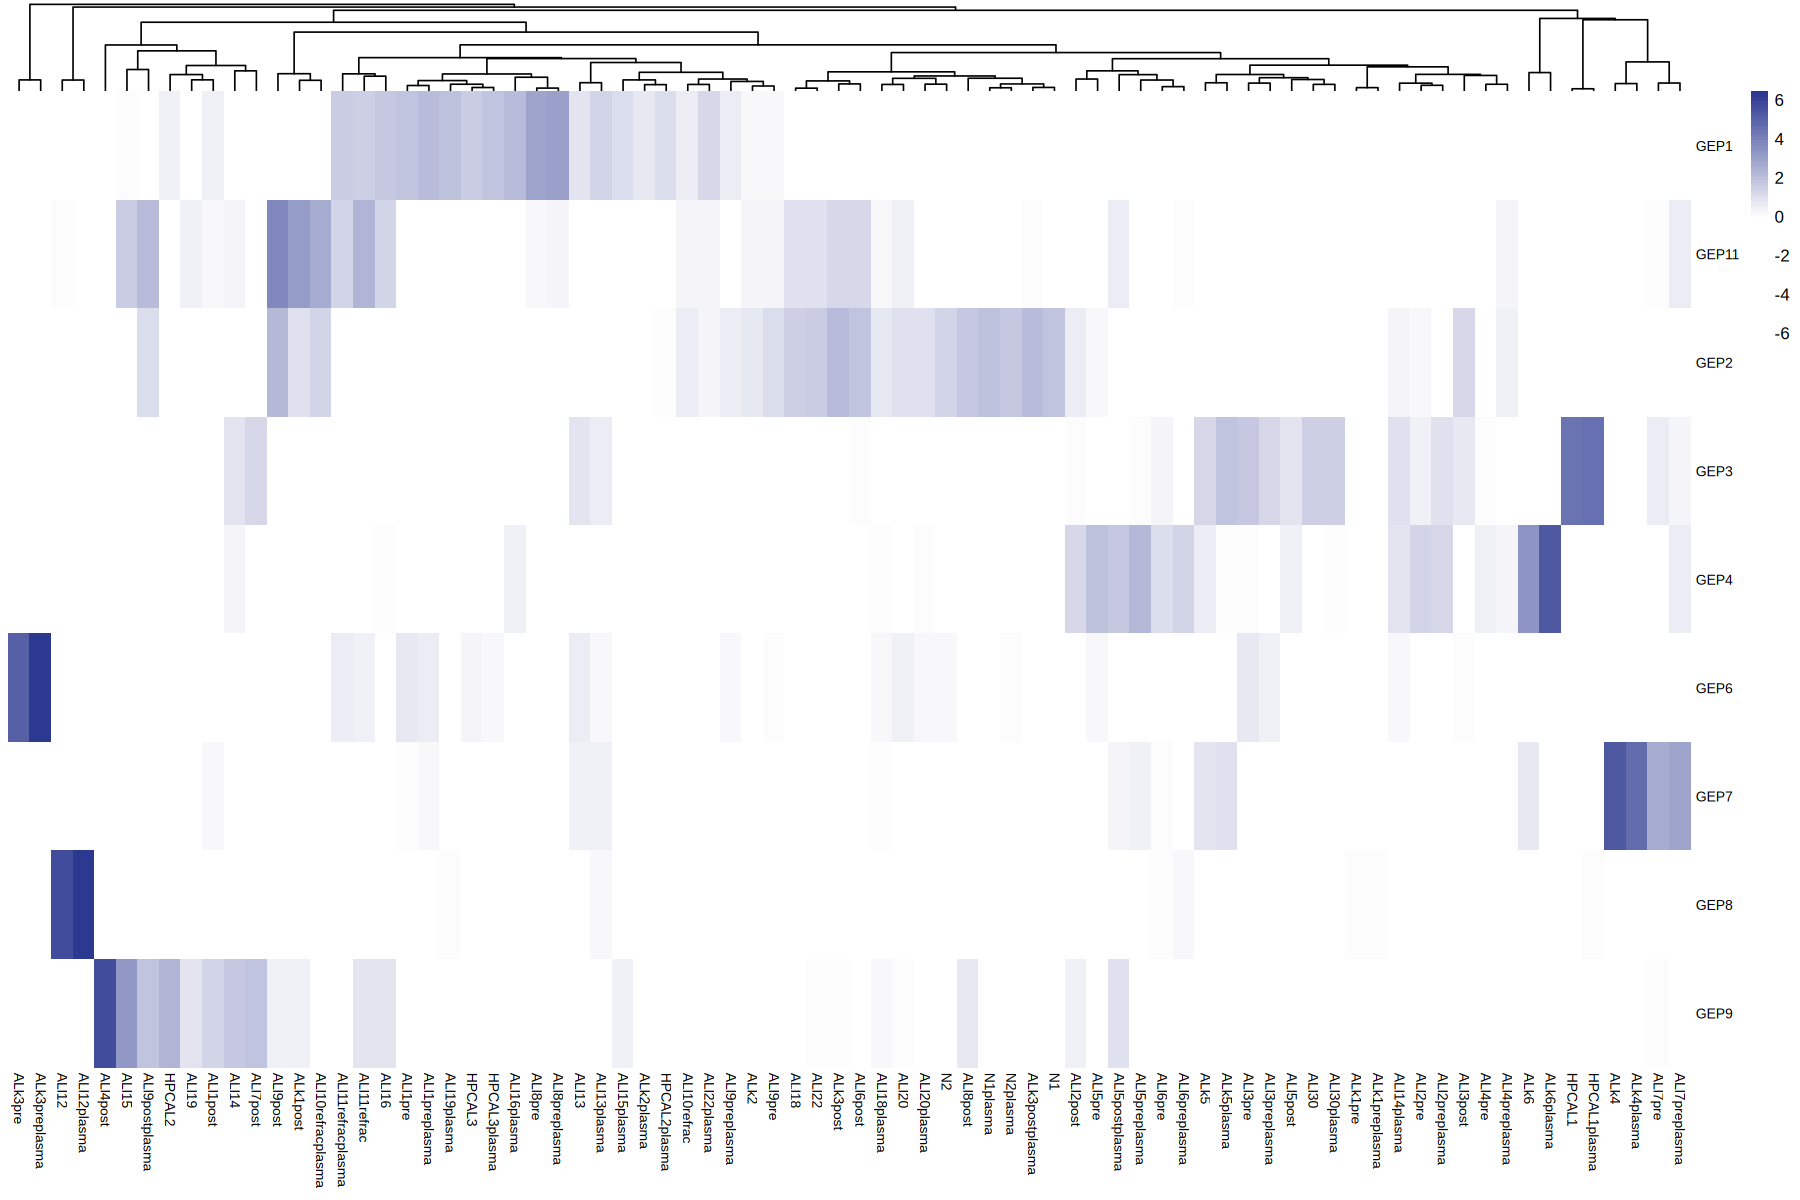

In [31]:
library(tibble)
library(dplyr)
library(pheatmap)

options(repr.plot.height=10,repr.plot.width=15)

# 1. Extract metadata
meta <- sce1_plasma@meta.data

# 2. Define the features and the group
features <- c('GEP1','GEP11','GEP2','GEP3','GEP4','GEP6','GEP7','GEP8','GEP9')

# 3. Calculate average per 
avg_mat <- meta %>%
  group_by(sample_id) %>%
  summarise(across(all_of(features), mean, na.rm = TRUE)) %>%
  column_to_rownames("sample_id") %>%
  t()  # Transpose to get features as rows and orig.ident as columns

# 4. Plot the heatmap
pheatmap(avg_mat,
         scale = "row",  # Optional: standardize across features
  border = FALSE,
  cluster_rows = FALSE,
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  color = colorRampPalette(c("white", "white", "#2c3991"))(100),
  fontsize_row = 8,  # Increased font size for gene names
  fontsize_col = 8,
  show_rownames = TRUE,
  show_colnames = TRUE)

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=0.61' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=0.61' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=-0.46' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=-0.46' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=-0.24' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ=-0.24' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphic

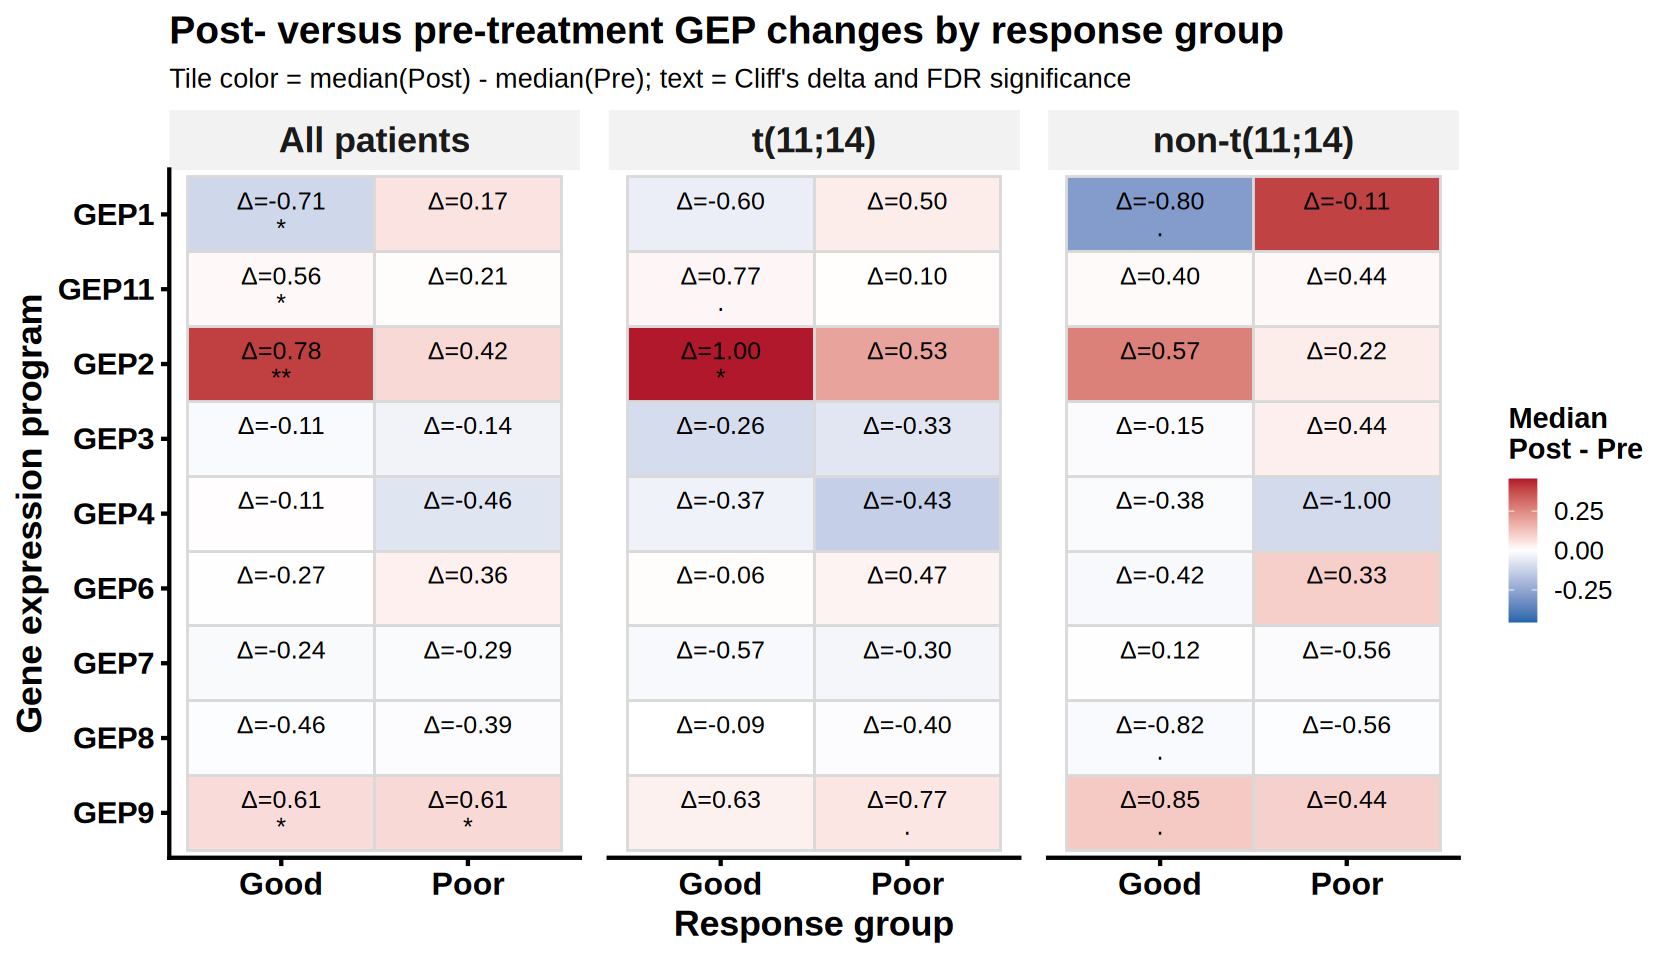

In [41]:
# ============================================================
# Simplified analysis:
# Post vs Pre GEP change by response group
# Faceted by All patients / t(11;14) / non-t(11;14)
# One PDF output only
#
# Fill = median(Post) - median(Pre)
# Text = Cliff's delta + FDR significance
# ============================================================

options(repr.plot.height = 8, repr.plot.width = 14)

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(stringr)
  library(scales)
})

# -----------------------------
# 0) Input settings
# -----------------------------
df <- boxplot

usage_feats <- c(
  "GEP1", "GEP11", "GEP2", "GEP3",
  "GEP4", "GEP6", "GEP7", "GEP8", "GEP9"
)

usage_feats <- intersect(usage_feats, colnames(df))

response_col <- "response"   # e.g. CR_pre, VGPR_post, PR_pre
cyto_col     <- "mut"        # cytogenetic annotation column

min_n_per_timepoint <- 2

out_dir <- "GEP_prepost_simplified"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

stopifnot(response_col %in% colnames(df))
stopifnot(cyto_col %in% colnames(df))
stopifnot(length(usage_feats) > 0)

# -----------------------------
# 1) Helper functions
# -----------------------------
p_to_star <- function(p) {
  case_when(
    is.na(p)  ~ "",
    p < 0.001 ~ "***",
    p < 0.01  ~ "**",
    p < 0.05  ~ "*",
    p < 0.10  ~ ".",
    TRUE      ~ ""
  )
}

safe_wilcox <- function(post, pre) {
  post <- post[is.finite(post)]
  pre  <- pre[is.finite(pre)]

  if (length(post) < min_n_per_timepoint || length(pre) < min_n_per_timepoint) {
    return(NA_real_)
  }

  tryCatch(
    wilcox.test(post, pre, exact = FALSE)$p.value,
    error = function(e) NA_real_
  )
}

cliffs_delta_manual <- function(x, y) {
  x <- x[is.finite(x)]
  y <- y[is.finite(y)]

  if (length(x) == 0 || length(y) == 0) return(NA_real_)

  sum(sign(outer(x, y, "-"))) / (length(x) * length(y))
}

safe_cliff_delta <- function(post, pre) {
  post <- post[is.finite(post)]
  pre  <- pre[is.finite(pre)]

  if (length(post) < min_n_per_timepoint || length(pre) < min_n_per_timepoint) {
    return(NA_real_)
  }

  tryCatch(
    cliffs_delta_manual(post, pre),
    error = function(e) NA_real_
  )
}

# -----------------------------
# 2) Build long-format table
# -----------------------------
gep_long <- df %>%
  mutate(
    sample_id = rownames(df),

    response_raw = .data[[response_col]],
    cyto_raw = as.character(.data[[cyto_col]]),

    timepoint = case_when(
      grepl("_pre$", response_raw, ignore.case = TRUE)  ~ "Pre",
      grepl("_post$", response_raw, ignore.case = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_detail = str_replace(response_raw, "_(pre|post)$", ""),

    response_group = case_when(
      response_detail %in% c("CR", "VGPR") ~ "Good",
      response_detail %in% c("PR", "SD", "NR", "PD", "NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    t1114_status = case_when(
      grepl(
        "t\\(11;14\\)|11;14|CCND1|IGH.?CCND1|IgH.?CCND1",
        cyto_raw,
        ignore.case = TRUE
      ) ~ "t(11;14)",
      TRUE ~ "non-t(11;14)"
    ),

    timepoint = factor(timepoint, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    t1114_status = factor(t1114_status, levels = c("t(11;14)", "non-t(11;14)"))
  ) %>%
  pivot_longer(
    cols = all_of(usage_feats),
    names_to = "GEP",
    values_to = "score"
  ) %>%
  filter(
    !is.na(timepoint),
    !is.na(response_group),
    !is.na(score)
  ) %>%
  mutate(
    GEP = factor(GEP, levels = rev(usage_feats))
  )

# Add three analysis facets:
# 1) All patients
# 2) t(11;14)
# 3) non-t(11;14)
gep_long_facet <- bind_rows(
  gep_long %>%
    mutate(analysis_group = "All patients"),

  gep_long %>%
    mutate(analysis_group = as.character(t1114_status))
) %>%
  mutate(
    analysis_group = factor(
      analysis_group,
      levels = c("All patients", "t(11;14)", "non-t(11;14)")
    )
  )

# -----------------------------
# 3) Compute Post - Pre changes
# -----------------------------
gep_stats <- gep_long_facet %>%
  group_by(analysis_group, response_group, GEP) %>%
  summarise(
    n_pre  = sum(timepoint == "Pre"  & is.finite(score)),
    n_post = sum(timepoint == "Post" & is.finite(score)),

    median_pre  = median(score[timepoint == "Pre"],  na.rm = TRUE),
    median_post = median(score[timepoint == "Post"], na.rm = TRUE),

    delta_median = median_post - median_pre,

    p_value = safe_wilcox(
      post = score[timepoint == "Post"],
      pre  = score[timepoint == "Pre"]
    ),

    cliff_delta = safe_cliff_delta(
      post = score[timepoint == "Post"],
      pre  = score[timepoint == "Pre"]
    ),

    .groups = "drop"
  ) %>%
  group_by(analysis_group) %>%
  mutate(
    q_value = p.adjust(p_value, method = "BH"),
    sig = p_to_star(q_value)
  ) %>%
  ungroup() %>%
  mutate(
    cliff_label = ifelse(
      is.na(cliff_delta),
      "Δ=NA",
      paste0("Δ=", number(cliff_delta, accuracy = 0.01))
    ),

    label = paste0(
      cliff_label,
      "\n",
      sig
    )
  )

write.csv(
  gep_stats,
  file.path(out_dir, "GEP_PostMinusPre_stats_by_response_t1114.csv"),
  row.names = FALSE
)

# -----------------------------
# 4) Single heatmap plot
# -----------------------------
max_abs_delta <- max(abs(gep_stats$delta_median), na.rm = TRUE)
if (!is.finite(max_abs_delta) || max_abs_delta == 0) max_abs_delta <- 1

p <- ggplot(
  gep_stats,
  aes(x = response_group, y = GEP, fill = delta_median)
) +
  geom_tile(color = "grey85", linewidth = 0.6) +

  geom_text(
    aes(label = label),
    size = 5.2,
    color = "black",
    lineheight = 0.9
  ) +

  scale_fill_gradient2(
    low = "#2166AC",
    mid = "white",
    high = "#B2182B",
    midpoint = 0,
    limits = c(-max_abs_delta, max_abs_delta),
    name = "Median\nPost - Pre"
  ) +

  facet_wrap(
    ~ analysis_group,
    nrow = 1
  ) +

  labs(
    x = "Response group",
    y = "Gene expression program",
    title = "Post- versus pre-treatment GEP changes by response group",
    subtitle = "Tile color = median(Post) - median(Pre); text = Cliff's delta and FDR significance"
  ) +

  theme_classic(base_size = 20) +
  theme(
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold", size = 21),

    axis.title = element_text(face = "bold", size = 21),
    axis.text.x = element_text(face = "bold", size = 19),
    axis.text.y = element_text(face = "bold", size = 18),

    plot.title = element_text(face = "bold", size = 23),
    plot.subtitle = element_text(size = 16),

    legend.title = element_text(face = "bold", size = 17),
    legend.text = element_text(size = 15),

    panel.spacing = unit(1.2, "lines")
  )

print(p)

ggsave(
  file.path(out_dir, "GEP_PostMinusPre_GoodPoor_All_t1114_non_t1114.pdf"),
  p,
  width = 14,
  height = 7.5,
  device = cairo_pdf
)

## 9. Simplified analysis


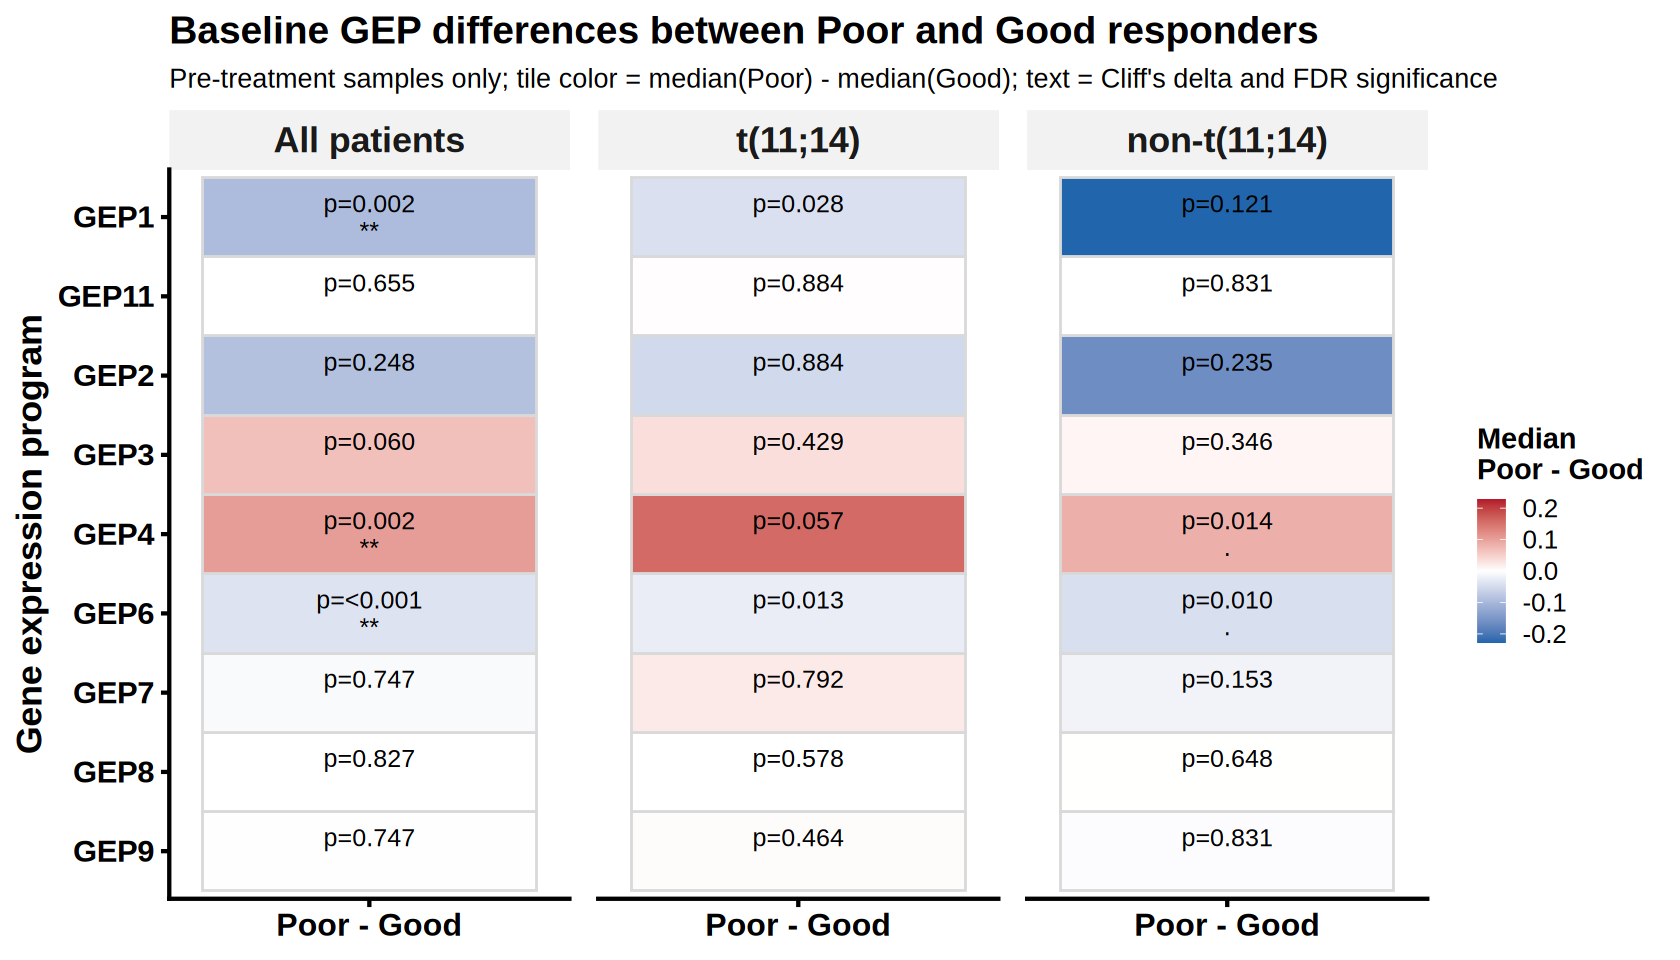

In [43]:
# ============================================================
# Simplified analysis:
# Pre-treatment only
# Compare Poor vs Good responders
# Faceted by All patients / t(11;14) / non-t(11;14)
# One PDF output only
#
# Fill = median(Poor) - median(Good) among pre-treatment samples
# Text = Cliff's delta + FDR significance
# ============================================================

options(repr.plot.height = 8, repr.plot.width = 14)

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(stringr)
  library(scales)
})

# -----------------------------
# 0) Input settings
# -----------------------------
df <- boxplot

usage_feats <- c(
  "GEP1", "GEP11", "GEP2", "GEP3",
  "GEP4", "GEP6", "GEP7", "GEP8", "GEP9"
)

usage_feats <- intersect(usage_feats, colnames(df))

response_col <- "response"   # e.g. CR_pre, VGPR_post, PR_pre
cyto_col     <- "mut"        # cytogenetic annotation column

min_n_per_group <- 2

out_dir <- "GEP_pretreatment_GoodPoor"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

stopifnot(response_col %in% colnames(df))
stopifnot(cyto_col %in% colnames(df))
stopifnot(length(usage_feats) > 0)

# -----------------------------
# 1) Helper functions
# -----------------------------
p_to_star <- function(p) {
  case_when(
    is.na(p)  ~ "",
    p < 0.001 ~ "***",
    p < 0.01  ~ "**",
    p < 0.05  ~ "*",
    p < 0.10  ~ ".",
    TRUE      ~ ""
  )
}

safe_wilcox <- function(poor, good) {
  poor <- poor[is.finite(poor)]
  good <- good[is.finite(good)]

  if (length(poor) < min_n_per_group || length(good) < min_n_per_group) {
    return(NA_real_)
  }

  tryCatch(
    wilcox.test(poor, good, exact = FALSE)$p.value,
    error = function(e) NA_real_
  )
}

cliffs_delta_manual <- function(x, y) {
  x <- x[is.finite(x)]
  y <- y[is.finite(y)]

  if (length(x) == 0 || length(y) == 0) return(NA_real_)

  sum(sign(outer(x, y, "-"))) / (length(x) * length(y))
}

safe_cliff_delta <- function(poor, good) {
  poor <- poor[is.finite(poor)]
  good <- good[is.finite(good)]

  if (length(poor) < min_n_per_group || length(good) < min_n_per_group) {
    return(NA_real_)
  }

  tryCatch(
    cliffs_delta_manual(poor, good),
    error = function(e) NA_real_
  )
}

# -----------------------------
# 2) Build long-format table
# -----------------------------
gep_long <- df %>%
  mutate(
    sample_id = rownames(df),

    response_raw = .data[[response_col]],
    cyto_raw = as.character(.data[[cyto_col]]),

    timepoint = case_when(
      grepl("_pre$", response_raw, ignore.case = TRUE)  ~ "Pre",
      grepl("_post$", response_raw, ignore.case = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_detail = str_replace(response_raw, "_(pre|post)$", ""),

    response_group = case_when(
      response_detail %in% c("CR", "VGPR") ~ "Good",
      response_detail %in% c("PR", "SD", "NR", "PD", "NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    t1114_status = case_when(
      grepl(
        "t\\(11;14\\)|11;14|CCND1|IGH.?CCND1|IgH.?CCND1",
        cyto_raw,
        ignore.case = TRUE
      ) ~ "t(11;14)",
      TRUE ~ "non-t(11;14)"
    ),

    timepoint = factor(timepoint, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    t1114_status = factor(t1114_status, levels = c("t(11;14)", "non-t(11;14)"))
  ) %>%
  pivot_longer(
    cols = all_of(usage_feats),
    names_to = "GEP",
    values_to = "score"
  ) %>%
  filter(
    timepoint == "Pre",
    !is.na(response_group),
    !is.na(score)
  ) %>%
  mutate(
    GEP = factor(GEP, levels = rev(usage_feats))
  )

# Add three analysis facets:
# 1) All patients
# 2) t(11;14)
# 3) non-t(11;14)
gep_long_facet <- bind_rows(
  gep_long %>%
    mutate(analysis_group = "All patients"),

  gep_long %>%
    mutate(analysis_group = as.character(t1114_status))
) %>%
  mutate(
    analysis_group = factor(
      analysis_group,
      levels = c("All patients", "t(11;14)", "non-t(11;14)")
    )
  )

# -----------------------------
# 3) Compute Poor vs Good difference at baseline
# -----------------------------
gep_stats <- gep_long_facet %>%
  group_by(analysis_group, GEP) %>%
  summarise(
    n_good = sum(response_group == "Good" & is.finite(score)),
    n_poor = sum(response_group == "Poor" & is.finite(score)),

    median_good = median(score[response_group == "Good"], na.rm = TRUE),
    median_poor = median(score[response_group == "Poor"], na.rm = TRUE),

    delta_median = median_poor - median_good,

    p_value = safe_wilcox(
      poor = score[response_group == "Poor"],
      good = score[response_group == "Good"]
    ),

    .groups = "drop"
  ) %>%
  group_by(analysis_group) %>%
  mutate(
    q_value = p.adjust(p_value, method = "BH"),
    sig = p_to_star(q_value)
  ) %>%
  ungroup() %>%
  mutate(
    comparison = "Poor - Good",

    p_label = ifelse(
      is.na(p_value),
      "p=NA",
      paste0("p=", pvalue(p_value, accuracy = 0.001))
    ),

    label = paste0(
      p_label,
      "\n",
      sig
    )
  )

write.csv(
  gep_stats,
  file.path(out_dir, "Pretreatment_GEP_Poor_vs_Good_stats_by_t1114.csv"),
  row.names = FALSE
)

# -----------------------------
# 4) Single heatmap plot
# -----------------------------
max_abs_delta <- max(abs(gep_stats$delta_median), na.rm = TRUE)
if (!is.finite(max_abs_delta) || max_abs_delta == 0) max_abs_delta <- 1

p <- ggplot(
  gep_stats,
  aes(x = comparison, y = GEP, fill = delta_median)
) +
  geom_tile(color = "grey85", linewidth = 0.6) +

  geom_text(
    aes(label = label),
    size = 5.2,
    color = "black",
    lineheight = 0.9
  ) +

  scale_fill_gradient2(
    low = "#2166AC",
    mid = "white",
    high = "#B2182B",
    midpoint = 0,
    limits = c(-max_abs_delta, max_abs_delta),
    name = "Median\nPoor - Good"
  ) +

  facet_wrap(
    ~ analysis_group,
    nrow = 1
  ) +

  labs(
    x = NULL,
    y = "Gene expression program",
    title = "Baseline GEP differences between Poor and Good responders",
    subtitle = "Pre-treatment samples only; tile color = median(Poor) - median(Good); text = Cliff's delta and FDR significance"
  ) +

  theme_classic(base_size = 20) +
  theme(
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text = element_text(face = "bold", size = 21),

    axis.title = element_text(face = "bold", size = 21),
    axis.text.x = element_text(face = "bold", size = 19),
    axis.text.y = element_text(face = "bold", size = 18),

    plot.title = element_text(face = "bold", size = 23),
    plot.subtitle = element_text(size = 16),

    legend.title = element_text(face = "bold", size = 17),
    legend.text = element_text(size = 15),

    panel.spacing = unit(1.2, "lines")
  )

print(p)

ggsave(
  file.path(out_dir, "Pretreatment_GEP_Poor_vs_Good_All_t1114_non_t1114.pdf"),
  p,
  width = 11,
  height = 7.5,
  device = cairo_pdf
)